# Rendering for Gaussian Splatting

In this notebook, we will implement a rendering algorithm for [Gaussian Splatting.](https://repo-sam.inria.fr/fungraph/3d-gaussian-splatting/3d_gaussian_splatting_high.pdf)

The rendering algorithm we are going to implement takes projected gaussian splats as input and returns an image. To extend the algorithm for 3D gaussian splats, one should additionally implement method for projecting 3D splats onto a camera.

The implementation will be based purely on PyTorch, whereas the common impelemntations rely on custom CUDA/OpenGL code for higher efficiency. This notebook partially adopts code [this](https://github.com/hbb1/torch-splatting) implementation.

Cool website for splats vizualization: [click](https://superspl.at/editor)

## Classes for Camera and 2D Point Cloud

In [1]:
!pip install plyfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pylab as plt
import cv2
import gc

from plyfile import PlyData
from IPython.display import clear_output

class Camera(nn.Module):
    def __init__(self, width=256, height=256):
        super().__init__()
        self.image_width = 256
        self.image_height = 256

class PointCloud2D(nn.Module):
    def __init__(self, n_splats, camera):
        super().__init__()
        initial_parameters = self._initialize_parameters(n_splats, camera)
        for parameter_name, tensor in initial_parameters.items():
            self.register_parameter(parameter_name, nn.Parameter(tensor))
        # In this example, we will not be tuning depth
        self.register_buffer('_depths', torch.rand(n_splats, 1))

    def _initialize_parameters(self, n_splats, camera):
        init_parameters = {}
        init_parameters['_means2d'] = torch.stack(
            [camera.image_width * torch.rand(n_splats),
             camera.image_height * torch.rand(n_splats)],
            dim=-1)
        init_parameters['_scaling'] = torch.randn(n_splats, 2) + 3.
        init_parameters['_rotation_angle'] = 2 * torch.pi * torch.rand(n_splats)
        init_parameters['_colors'] = torch.rand(n_splats, 3)
        init_parameters['_opacity'] = torch.randn(n_splats, 1)
        return init_parameters

    def forward(self):
        cos_phi = self._rotation_angle.cos()
        sin_phi = self._rotation_angle.sin()
        rotation_matrix = torch.stack(
            [torch.stack([cos_phi, -sin_phi], dim=-1),
             torch.stack([sin_phi, cos_phi], dim=-1)],
            dim=-1,
        )
        # scaling_dianogal = F.softplus(self._scaling)
        scaling_diagonal = torch.exp(self._scaling)
        cov2d = torch.einsum(
            'bij,bj,bkj->bik',
            rotation_matrix,
            scaling_diagonal,
            rotation_matrix
        )
        opacity = F.sigmoid(self._opacity)
        output_dict = {
            'means2d': self._means2d,
            'cov2d': cov2d,
            'colors': self._colors,
            'opacity': opacity,
            'depths': self._depths
        }
        return output_dict

Our goal today is to write an algorithm that outputs something similar to `plt.scatter`.

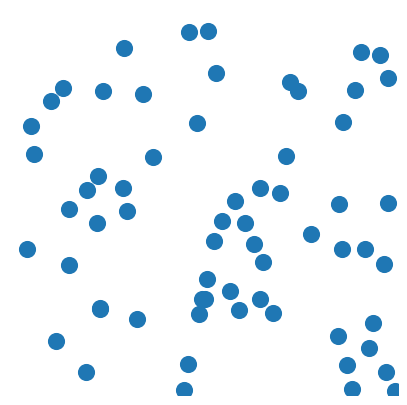

In [3]:
n_splats = 64
camera = Camera()
pc = PointCloud2D(n_splats, camera)

pc_outputs = pc()
means2d = pc_outputs['means2d'].detach()
colors = pc_outputs['colors'].detach()

plt.figure(figsize=(5, 5))
plt.scatter(
    means2d[:, 0],
    camera.image_height - means2d[:, 1],
    # c=colors,
    s=128
)
plt.xlim(0, camera.image_width)
plt.ylim(0, camera.image_height)
plt.axis('off');

This is the renderer implementation. You goal is to implement methods `get_alpha` and `compose_alpha` for rendering. Additionally, you should implement method `get_raduis` to improve rendering efficiency. The method computes the radius of a circle contatining the Gaussian.

We will denote number of pixels as `P` and number of Gaussians as `G`.

In [4]:
class GaussianRenderer(nn.Module):
    def __init__(self, camera, background_color=None):
        super().__init__()
        self.image_width = camera.image_width
        self.image_height = camera.image_height
        self.register_buffer(
            'pix_coord',
            torch.stack(
                torch.meshgrid(torch.arange(self.image_width),
                               torch.arange(self.image_height),
                               indexing='xy'),
                dim=-1)
        )
        if background_color is None:
            background_color = torch.ones(3)
        self.register_buffer('background_color', background_color)
        self.tile_size = 64

    @torch.no_grad()
    def get_radius(self, cov2d):
        """
        cov2d is a tensor of shape [G, 2, 2]

        output tensor shape is expected to be [G]

        Computes a pixel-space radius for each 2D Gaussian by taking
        3 * sqrt(lambda_max) (3-sigma rule), where lambda_max is the largest eigenvalue of the
        2x2 covariance matrix.
        """
        det = cov2d[:, 0, 0] * cov2d[:,1,1] - cov2d[:, 0, 1] * cov2d[:,1,0]
        mid = 0.5 * (cov2d[:, 0,0] + cov2d[:,1,1])
        radius_squared = mid + torch.sqrt((mid**2-det).abs())
        return 3.0 * torch.sqrt(radius_squared.abs()).ceil()

    @torch.no_grad()
    def get_rect(self, means2d, radii):
        """
        Computes the screen-space Axis-Aligned Bounding Box (AABB) for each Gaussian.

        It constructs a bounding square using the Gaussian's 2D center and its
        computed radius. The resulting Top-Left (rect_min) and Bottom-Right
        (rect_max) coordinates are strictly clipped to the image boundaries to
        prevent out-of-bounds rendering and optimize tile rejecting.
        """
        rect_min = (means2d - radii[:,None])
        rect_max = (means2d + radii[:,None])
        rect_min[..., 0] = rect_min[..., 0].clip(0, self.image_width - 1.0)
        rect_min[..., 1] = rect_min[..., 1].clip(0, self.image_height - 1.0)
        rect_max[..., 0] = rect_max[..., 0].clip(0, self.image_width - 1.0)
        rect_max[..., 1] = rect_max[..., 1].clip(0, self.image_height - 1.0)
        return rect_min, rect_max

    def get_in_mask(self, rect, w, h):
        """
        Determines which Gaussian bounding boxes intersect with a specific screen tile.

        It computes the intersection between the Gaussian's AABB and the tile's
        boundaries (defined by top-left (w, h) and bottom-right (w + tile_size - 1,
        h + tile_size - 1)). A boolean mask is returned, marking Gaussians that
        overlap the tile with True, effectively culling the rest.
        """
        over_tl = (
            rect[0][..., 0].clip(min=w),
            rect[0][..., 1].clip(min=h)
        )
        over_br = (
            rect[1][..., 0].clip(max=w+self.tile_size-1),
            rect[1][..., 1].clip(max=h+self.tile_size-1)
        )
        in_mask = (over_br[0] > over_tl[0]) & (over_br[1] > over_tl[1]) # gaussian in the tile
        return in_mask

    def get_alpha(self, x, means2d, cov2d, opacity):
        """
        Computes the opacity (alpha) of each Gaussian at every pixel within a tile.

        It evaluates the unnormalized 2D Gaussian probability density function
        evaluating exp(-0.5 * dx^T * Sigma^-1 * dx) for each pixel-Gaussian pair.
        and then scaling by the Gaussian's base opacity.

        x is a tensor with shape [P x 2]
        means2d is a tensor with shape [G x 2]
        cov2 is a tensor with shape [G x 2 x 2]
        opacity is a tensor with shape [G, 1]

        output tensor shape is expected to be [B, P, 1]
        """
        dx = x[:, None, :] - means2d[None]
        gauss_weight = torch.exp(-0.5 * torch.einsum('bpi,pij,bpj->bp', dx, cov2d.inverse(), dx))
        alpha = (gauss_weight.unsqueeze(-1) * opacity[None]).clip(max=0.99) # B P 1
        return alpha

    def compose_alpha(self, alpha, values):
        """
        Performs alpha compositing for a set of depth-sorted Gaussians along
        each pixel's ray.
        It calculates the transmittance T_i for each Gaussian as the cumulative
        product of (1 - alpha) of all preceding Gaussians. The final pixel value
        (color or depth) is computed as the sum of T_i * alpha_i * value_i.

        alpha is a tensor with shape [B, P, 1]
        values is a tensor with shape [P, C]

        output tensor shapes are expected to be [B, C] and [B]
        """
        T = torch.cat([torch.ones_like(alpha[:,:1]), 1-alpha[:,:-1]], dim=1).cumprod(dim=1)
        accumulated_alpha = (alpha * T).sum(dim=1)
        composed_values = (T * alpha * values[None]).sum(dim=1)
        return composed_values, accumulated_alpha

    def get_empty_tile(self,):
        tile_shape = (self.tile_size, self.tile_size, 1)
        device = self.background_color.device
        tile_color = self.background_color * torch.ones(*tile_shape, device=device)
        tile_alpha = torch.zeros(*tile_shape, device=device)
        return tile_color, tile_alpha

    def forward(self, camera, means2d, cov2d, colors, opacity, depths):
        radii = self.get_radius(cov2d)
        rect = self.get_rect(means2d, radii)
        render_color = []
        render_alpha = []
        for h in range(0, self.image_height, self.tile_size):
            render_color_h = []
            render_alpha_h = []
            for w in range(0, self.image_width, self.tile_size):
                in_mask = self.get_in_mask(rect, w, h)
                if not torch.any(in_mask):
                    tile_color, tile_alpha = self.get_empty_tile()
                    render_color_h.append(tile_color)
                    render_alpha_h.append(tile_alpha)
                    continue

                # cull and sort
                _, index = torch.sort(depths[..., 0][in_mask])
                cull_and_sort = lambda x: x[in_mask][index]
                tile_depths = cull_and_sort(depths)
                tile_means2d = cull_and_sort(means2d)
                tile_cov2d = cull_and_sort(cov2d) # G 2 2
                tile_opacity = cull_and_sort(opacity)
                tile_colors = cull_and_sort(colors)

                tile_coord = self.pix_coord[h:h+self.tile_size, w:w+self.tile_size].flatten(0,-2)
                alpha = self.get_alpha(
                    tile_coord,
                    tile_means2d,
                    tile_cov2d,
                    tile_opacity
                )

                tile_color, acc_alpha = self.compose_alpha(alpha, tile_colors)
                tile_color = tile_color + (1 - acc_alpha) * self.background_color
                tile_depth, _ = self.compose_alpha(alpha, tile_depths)

                render_color_h.append(tile_color.reshape(self.tile_size, self.tile_size, -1))
                render_alpha_h.append(acc_alpha.reshape(self.tile_size, self.tile_size, -1))
            render_color.append(torch.cat(render_color_h, dim=1))
            render_alpha.append(torch.cat(render_alpha_h, dim=1))
        render_color = torch.cat(render_color, dim=0)
        render_alpha = torch.cat(render_alpha, dim=0)
        return render_color, render_alpha

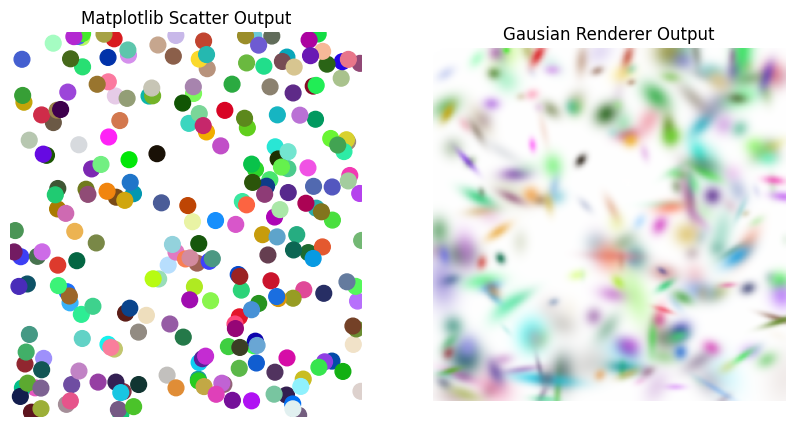

In [5]:
n_splats = 256
camera = Camera()
pc = PointCloud2D(n_splats, camera)
renderer = GaussianRenderer(camera)

pc_outputs = pc()
means2d = pc_outputs['means2d'].detach()
colors = pc_outputs['colors'].detach()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(
    means2d[:, 0],
    camera.image_height - means2d[:, 1],
    c=colors,
    s=128
)
ax[0].set_xlim(0, camera.image_width)
ax[0].set_ylim(0, camera.image_height)
ax[0].axis('off')
ax[0].set_title('Matplotlib Scatter Output')

color, _ = renderer(camera, **pc_outputs)

ax[1].imshow(color.detach().cpu())
ax[1].axis('off')
ax[1].set_title('Gausian Renderer Output');

let's try to train it

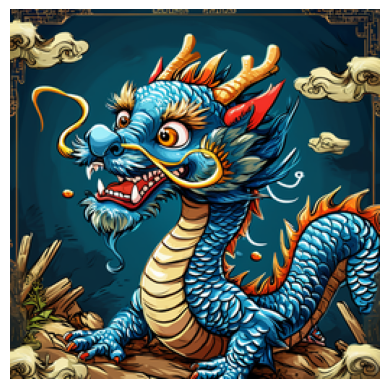

In [6]:
img = cv2.imread('dragon_2d.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))
plt.imshow(img)
plt.axis('off')

gt_image = torch.from_numpy(img).to('cuda:0') / 256

In [7]:
@torch.no_grad()
def plot_current_outputs(gt_image, image, alpha, epoch):
    loss = ((gt_image - image) ** 2).mean()
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    prepare_image = lambda x: x.detach().clamp(0., 1.).cpu()
    ax[0].set_title('Target')
    ax[0].imshow(prepare_image(gt_image))
    ax[0].axis('off')
    ax[1].set_title(f'Gaussian Splats, $L_2$={loss.item():.3f}, epoch={epoch}')
    ax[1].imshow(prepare_image(image))
    ax[1].axis('off')
    ax[2].set_title(r'$\alpha$')
    ax[2].imshow(prepare_image(alpha), cmap='inferno')
    ax[2].axis('off')
    clear_output(wait=True)
    plt.show()

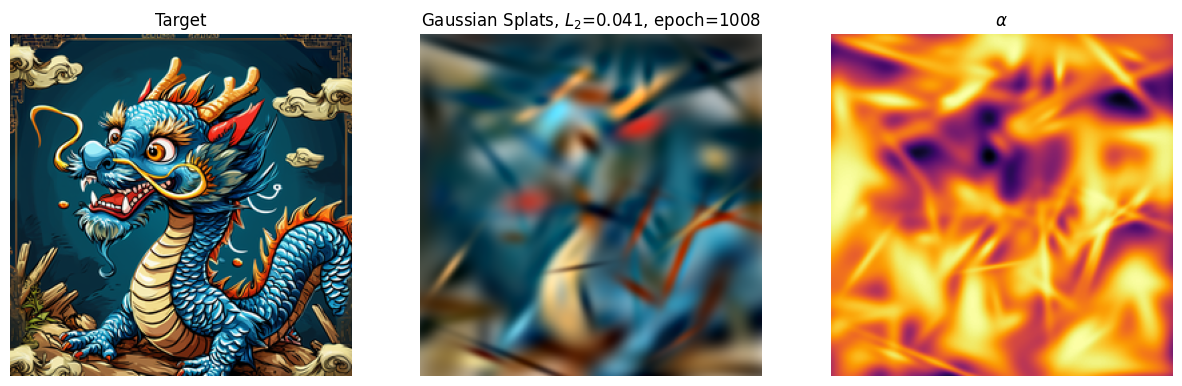

In [11]:
pc = PointCloud2D(128, camera)
pc = pc.to('cuda:0')
renderer = GaussianRenderer(camera)
renderer.to('cuda:0')
optim = torch.optim.Adam(pc.parameters(), lr=1e-2)

try:
    for i in range(1024):
        colors, alpha = renderer(camera, **pc())
        loss = ((gt_image - colors) ** 2).mean()
        loss.backward()
        optim.step()
        optim.zero_grad()
        if i % 16 == 0:
            plot_current_outputs(gt_image, colors, alpha, i)
except KeyboardInterrupt:
    plot_current_outputs(gt_image, colors, alpha)

In [12]:
del(pc)
del(renderer)
del(optim)
del(colors)
del(alpha)
del(loss)
torch.cuda.empty_cache()
gc.collect();

# 3d part

In [13]:
class LookAtCamera(Camera):
    def __init__(self, fov, position, target, upward_hint, width=256, height=256):
        super().__init__(width, height)
        self.register_buffer('fov', torch.tensor(fov, dtype=torch.float32)) # camera field of view
        self.register_buffer('position', torch.tensor(position, dtype=torch.float32))
        self.register_buffer('target', torch.tensor(target, dtype=torch.float32))
        self.register_buffer('upward_hint', torch.tensor(upward_hint, dtype=torch.float32)) # camera up vector

    def get_c2w(self):
        z_axis = F.normalize(self.target - self.position, dim=0)
        x_axis = F.normalize(torch.cross(self.upward_hint, z_axis), dim=0)
        y_axis = F.normalize(torch.cross(z_axis, x_axis), dim=0)
        R = torch.stack([x_axis, y_axis, z_axis], dim=1)
        c2w = torch.eye(4, dtype=torch.float32, device=self.position.device)
        c2w[:3, :3] = R
        c2w[:3, 3] = self.position
        return c2w

    def get_K(self):
        '''
        Intrinsic matrix
        '''
        f_y = (self.image_height / 2.0) / torch.tan(self.fov / 2.0)
        f_x = f_y
        c_x = self.image_width / 2.0
        c_y = self.image_height / 2.0
        K = torch.tensor(
          [[f_x,  0., c_x, 0.],
           [ 0., f_y, c_y, 0.],
           [ 0.,  0.,  1., 0.],],
           device = self.fov.device
        )
        return K

class PointCloud3D(nn.Module):
    def __init__(self, ply_filename):
        super().__init__()
        initial_parameters = self._initialize_parameters(ply_filename)
        for parameter_name, tensor in initial_parameters.items():
            self.register_parameter(parameter_name, nn.Parameter(tensor))

    def _get_tensor_from_ply(self, ply, fields):
        scalar_arrays = [torch.asarray(ply['vertex'][key]) for key in fields]
        return torch.stack(scalar_arrays, dim=1)

    def _initialize_parameters(self, ply_filename):
        ply_file = PlyData.read(ply_filename)
        means = ['x', 'y', 'z']
        f_dcs = ['f_dc_0', 'f_dc_1', 'f_dc_2',]
        scale = ['scale_0', 'scale_1', 'scale_2']
        quats = ['rot_0', 'rot_1', 'rot_2', 'rot_3']
        opacity = ['opacity']
        init_parameters = {
            '_means' : self._get_tensor_from_ply(ply_file,  means),
            '_f_dcs' : self._get_tensor_from_ply(ply_file,  f_dcs), # spherical harmonics
            '_scale' : self._get_tensor_from_ply(ply_file,  scale),
            '_quats' : self._get_tensor_from_ply(ply_file,  quats), # quaternions
            '_opacity' : self._get_tensor_from_ply(ply_file, opacity)
        }
        return init_parameters

    @staticmethod
    def homogenize_points(points):
        ones = torch.ones_like(points[..., :1])
        return torch.cat([points, ones], dim=-1)

    @staticmethod
    def dehomogenize_points(points_hom):
        last_comp = points_hom[..., -1:].clone()
        last_comp[last_comp.abs() < 1e-6] = 1e-6 # Avoid division by zero
        return points_hom[..., :-1] / last_comp

    def forward(self, camera):
        # project means & get depths
        means3d_hom = self.homogenize_points(self._means)
        w2c = torch.inverse(camera.get_c2w())
        means2d_hom = means3d_hom @ w2c.T @ camera.get_K().T
        depths = means2d_hom[..., -1:]
        means2d = self.dehomogenize_points(means2d_hom)
        # TODO: compute scales
        # we force all Gaussians to be shaped like small round dots.
        n_points = means2d.shape[0]
        cov2d = 1e-1 * torch.eye(2, device=means2d.device)[None, ...].repeat(n_points, 1, 1)
        # compute colors
        colors = 0.5 * (0.282095 * self._f_dcs + 1.)
        opacity = F.sigmoid(self._opacity)
        # get opacity
        valid_mask = (depths > 0.).view(-1)
        output_dict = {
            'means2d': means2d[valid_mask],
            'cov2d': cov2d[valid_mask],
            'colors': colors[valid_mask],
            'opacity': opacity[valid_mask],
            'depths': depths[valid_mask]
        }
        return output_dict

/tmp/ipykernel_3626/2467032548.py:11: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  x_axis = F.normalize(torch.cross(self.upward_hint, z_axis), dim=0)


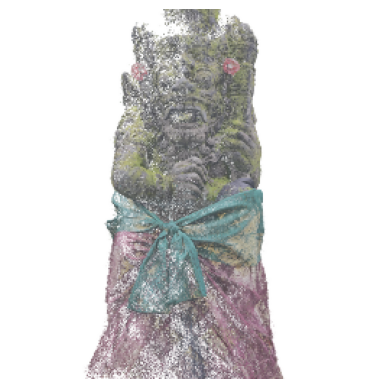

In [14]:
pc = PointCloud3D('Ubud.ply').to('cuda:0')
camera = LookAtCamera([0.3], [-2, 0.3, -3], [0, 0, 0], [0, 1, 0]).to('cuda:0')
renderer = GaussianRenderer(camera)
renderer.to('cuda:0')
renderer.tile_size = 32  # with tile size 64 I get CUDA OOM
with torch.no_grad():
    colors, alpha = renderer(camera, **pc(camera))

plt.imshow(colors.cpu())
plt.axis('off');

In [ ]:
del(pc)
del(camera)
del(renderer)
del(colors)
del(alpha)
torch.cuda.empty_cache()
gc.collect();